In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados do arquivo
try:
    with open('results/stats.json', 'r') as f:
        data = json.load(f)
except FileNotFoundError:
    print("Arquivo 'results/stats.json' não encontrado. Verifique o caminho.")
    # Se quiser testar sem o arquivo, descomente a linha abaixo e cole o JSON bruto na variável data
    # data = json.loads(...) 

# Processar os dados para um formato tabular (DataFrame)
records = []
for entry in data:
    key = list(entry.keys())[0]
    values = entry[key]
    
    # Extrair benchmarks
    int_ops = values['benchmark']['integer_benchmark']['ops_per_second']
    float_ops = values['benchmark']['float_benchmark']['ops_per_second']
    
    # Lógica para pegar recursos (cores ou servers)
    # Se 'num_cores' for "distributed", pegamos 'num_servers'
    num_resources = values.get('num_cores')
    if num_resources == 'distributed':
        num_resources = values.get('num_servers')
    
    records.append({
        'Mode': key,
        'Time': values['time_seconds'],
        'Cores_Servers': num_resources, # Nome da coluna conforme seu exemplo
        'Int_Ops': int_ops,
        'Float_Ops': float_ops
    })

df = pd.DataFrame(records)

# Agrupar médias (necessário pois o modo distribuído tem 3 execuções)
# numeric_only=True evita erros com colunas de texto
df_avg = df.groupby('Mode').mean(numeric_only=True).reset_index()

# Ordenar para garantir a sequência: Linear -> Local -> Distribuído
order_map = {'Linear': 0, 'Parallel_Local': 1, 'Parallel_Distributed': 2}
df_avg['sort_val'] = df_avg['Mode'].map(order_map)
df_avg = df_avg.sort_values('sort_val').drop('sort_val', axis=1)

# Exibir tabela inicial
display(df_avg)

,Mode,Time,Cores_Servers,Int_Ops,Float_Ops
0,Linear,186.003009,1.0,2.877854e+09,2.951502e+08
1,Parallel_Local,80.786269,8.0,3.390412e+09,3.154671e+08


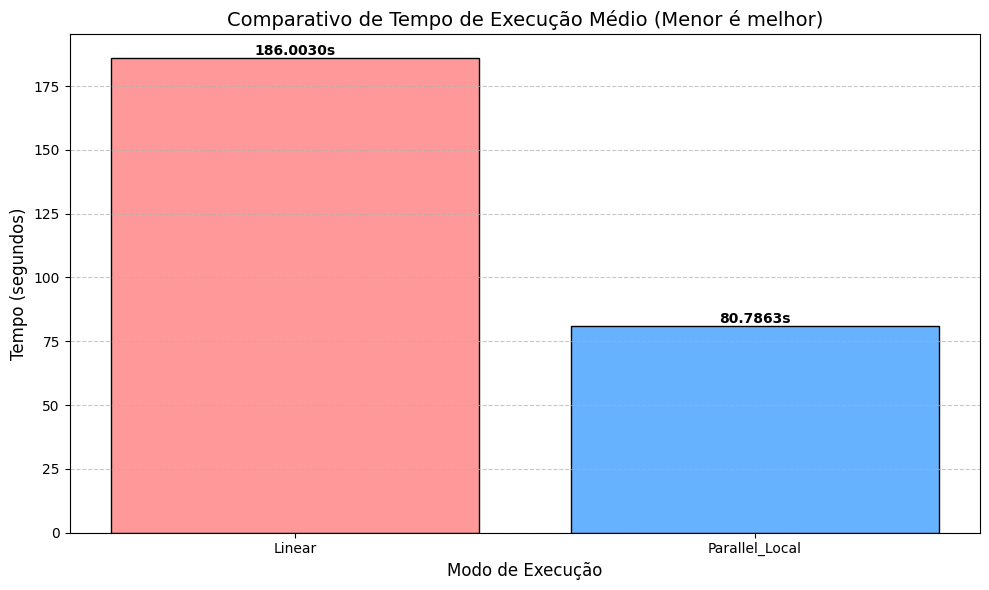

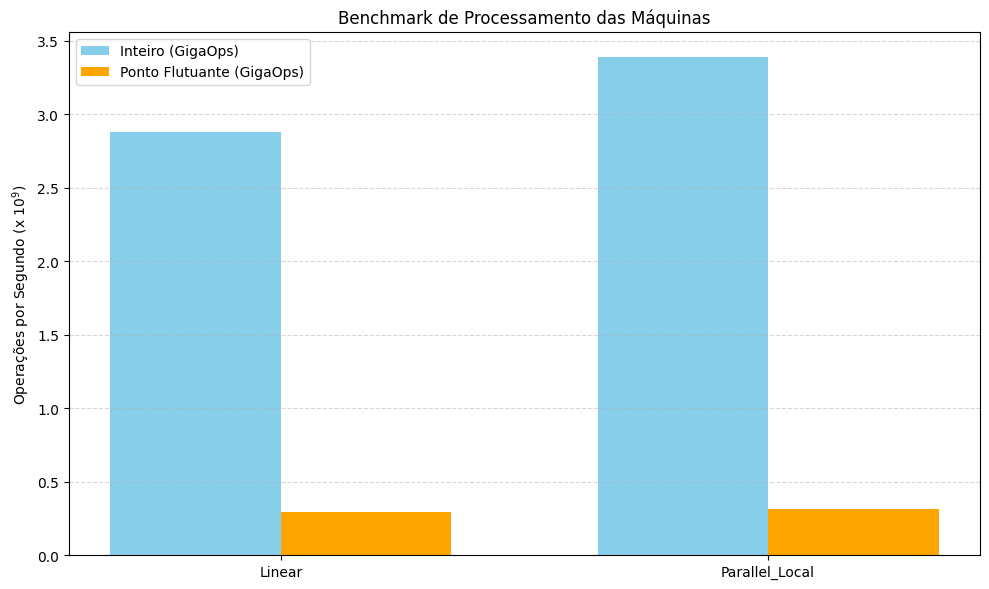

In [11]:
# --- Gráfico 1: Tempo de Execução ---
plt.figure(figsize=(10, 6))

colors = ['#FF9999', '#66B2FF', '#99FF99']
bars = plt.bar(df_avg['Mode'], df_avg['Time'], color=colors, edgecolor='black')

plt.title('Comparativo de Tempo de Execução Médio (Menor é melhor)', fontsize=14)
plt.ylabel('Tempo (segundos)', fontsize=12)
plt.xlabel('Modo de Execução', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar valores acima das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# --- Gráfico 2: Benchmarks (Inteiros vs Float) ---
modes = df_avg['Mode']
int_ops = df_avg['Int_Ops'] / 1e9  # Converter para GigaOps
float_ops = df_avg['Float_Ops'] / 1e9 # Converter para GigaOps

x = np.arange(len(modes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, int_ops, width, label='Inteiro (GigaOps)', color='skyblue')
rects2 = ax.bar(x + width/2, float_ops, width, label='Ponto Flutuante (GigaOps)', color='orange')

ax.set_ylabel('Operações por Segundo (x $10^9$)')
ax.set_title('Benchmark de Processamento das Máquinas')
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
# Tempo base (Linear) - Obtido dinamicamente do DataFrame
# Procura a linha onde Mode == 'Linear' e pega o tempo
try:
    t_serial = df_avg.loc[df_avg['Mode'] == 'Linear', 'Time'].values[0]
except IndexError:
    print("Erro: Modo 'Linear' não encontrado nos dados para cálculo base.")
    t_serial = 1 # Valor dummy para não quebrar o código

print(f"{'Modo':<25} | {'Tempo(s)':<10} | {'Recursos':<8} | {'Speedup (S)':<12} | {'Classificação':<15} | {'Eficiência (E)':<15}")
print("-" * 105)

for index, row in df_avg.iterrows():
    mode = row['Mode']
    t_paralelo = row['Time']
    
    # --- PONTO CHAVE: Recursos Dinâmicos ---
    # Pegamos o valor diretamente da coluna calculada no passo 1
    p = row['Cores_Servers'] 
    
    # Cálculo Speedup: S = T_serial / T_paralelo
    if mode == 'Linear':
        speedup = 1.0
        classificacao = "Base"
        eficiencia = 1.0
    else:
        speedup = t_serial / t_paralelo
        
        # Classificação do Speedup
        if round(speedup, 4) > p:
            classificacao = "Superlinear"
        elif round(speedup, 4) == p:
            classificacao = "Linear"
        else:
            classificacao = "Sublinear"
            
        # Cálculo Eficiência: E = S / P
        eficiencia = speedup / p

    print(f"{mode:<25} | {t_paralelo:<10.4f} | {int(p):<8} | {speedup:<12.4f} | {classificacao:<15} | {eficiencia:<15.4f}")

print("-" * 105)
print("\n* Speedup (S) = T_linear / T_paralelo")
print("* Eficiência (E) = S / Recursos")

Modo                      | Tempo(s)   | Recursos | Speedup (S)  | Classificação   | Eficiência (E) 
---------------------------------------------------------------------------------------------------------
Linear                    | 186.0030   | 1        | 1.0000       | Base            | 1.0000         
Parallel_Local            | 80.7863    | 8        | 2.3024       | Sublinear       | 0.2878         
---------------------------------------------------------------------------------------------------------

* Speedup (S) = T_linear / T_paralelo
* Eficiência (E) = S / Recursos
